In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ścieżka do surowych danych
raw_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\07_pytorch_cl\data\raw\RAW.csv"

# Wczytanie danych
df_raw = pd.read_csv(raw_path)

print("=" * 80)
print("SHAPE DANYCH SUROWYCH")
print("=" * 80)
print(f"Liczba wierszy: {df_raw.shape[0]}")
print(f"Liczba kolumn: {df_raw.shape[1]}")

print("\n" + "=" * 80)
print("NAZWY KOLUMN I TYPY DANYCH")
print("=" * 80)
print(df_raw.dtypes)

print("\n" + "=" * 80)
print("PIERWSZE 5 WIERSZY")
print("=" * 80)
print(df_raw.head())

print("\n" + "=" * 80)
print("BRAKUJĄCE WARTOŚCI")
print("=" * 80)
print(df_raw.isnull().sum())

print("\n" + "=" * 80)
print("STATYSTYKA OPISOWA - WSZYSTKIE KOLUMNY")
print("=" * 80)
print(df_raw.describe())

print("\n" + "=" * 80)
print("INFORMACJE O TYPACH DANYCH")
print("=" * 80)
print(df_raw.info())

print("\n" + "=" * 80)
print("ROZMIAR PLIKU")
print("=" * 80)
print(f"{df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

SHAPE DANYCH SUROWYCH
Liczba wierszy: 17975
Liczba kolumn: 38

NAZWY KOLUMN I TYPY DANYCH
Compound_CID                            int64
Name                                   object
Synonyms                               object
Molecular_Weight                      float64
Molecular_Formula                      object
Polar_Area                            float64
Complexity                            float64
XLogP                                 float64
Heavy_Atom_Count                        int64
H-Bond_Donor_Count                      int64
H-Bond_Acceptor_Count                   int64
Rotatable_Bond_Count                    int64
InChI                                  object
SMILES                                 object
InChIKey                               object
IUPAC_Name                             object
Exact_Mass                            float64
Monoisotopic_Mass                     float64
Charge                                  int64
Covalent_Unit_Count                 

KROK 1: USUNIĘCIE NIEPOTRZEBNYCH KOLUMN
Kolumny które pozostały: 8
Pozostałe kolumny:
['Molecular_Weight', 'Polar_Area', 'Complexity', 'XLogP', 'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count', 'SMILES']

KROK 2: ANALIZA BRAKUJĄCYCH WARTOŚCI XLogP

Brakujące wartości XLogP:
  Liczba całkowita wierszy: 17975
  Liczba brakujących XLogP: 5570
  Liczba dostępnych XLogP: 12405
  Procent brakujących: 30.99%

--------------------------------------------------------------------------------
STATYSTYKA DLA DOSTĘPNYCH WARTOŚCI XLogP
--------------------------------------------------------------------------------

Min: -61.1000
Max: 28.9000
Mean: 2.2900
Median: 2.6000
Std Dev: 4.8796
Q1 (25%): 0.7000
Q3 (75%): 4.2000

--------------------------------------------------------------------------------
ANALIZA OUTLIERS (metoda IQR)
--------------------------------------------------------------------------------
Dolna granica: -4.5500
Górna granica: 9.4500
Liczba outliers: 1192 (9.6

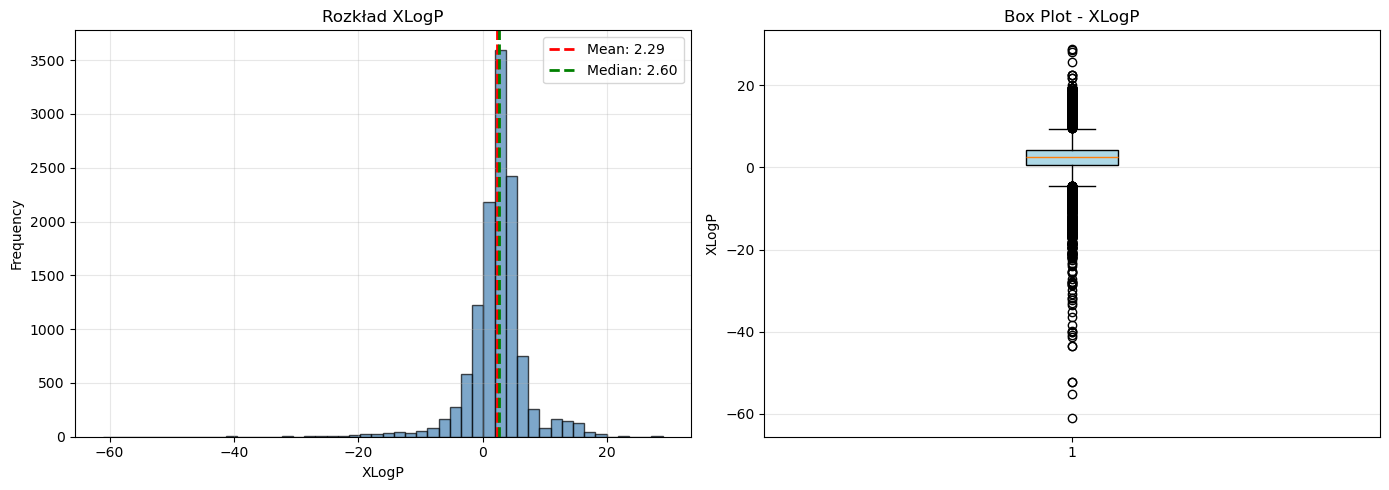

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ścieżka do surowych danych
raw_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\07_pytorch_cl\data\raw\RAW.csv"
df = pd.read_csv(raw_path)

# ===== KROK 1: USUŃ NIEPOTRZEBNE KOLUMNY =====
kolumny_do_usuniecia = [
    'Compound_CID', 'Name', 'Synonyms', 'Molecular_Formula', 'InChI', 'InChIKey', 
    'IUPAC_Name', 'MeSH_Headings', 'Annotation_Content', 'Linked_BioAssays', 
    'Create_Date', 'Data_Source', 'Data_Source_Category', 'Tagged_by_PubChem',
    'Heavy_Atom_Count', 'Exact_Mass', 'Monoisotopic_Mass', 'Charge', 
    'Covalent_Unit_Count', 'Isotopic_Atom_Count', 'Total_Atom_Stereo_Count',
    'Defined_Atom_Stereo_Count', 'Undefined_Atom_Stereo_Count', 'Total_Bond_Stereo_Count',
    'Defined_Bond_Stereo_Count', 'Undefined_Bond_Stereo_Count',
    'Linked_PubChem_Literature_Count', 'Linked_PubChem_Patent_Count',
    'Linked_PubChem_Patent_Family_Count', 'Annotation_Type_Count',
]

df = df.drop(columns=kolumny_do_usuniecia)

print("=" * 80)
print("KROK 1: USUNIĘCIE NIEPOTRZEBNYCH KOLUMN")
print("=" * 80)
print(f"Kolumny które pozostały: {df.shape[1]}")
print(f"Pozostałe kolumny:\n{df.columns.tolist()}\n")

# ===== KROK 2: ANALIZA XLogP NA OCZYSZCZONYCH DANYCH =====
print("=" * 80)
print("KROK 2: ANALIZA BRAKUJĄCYCH WARTOŚCI XLogP")
print("=" * 80)

n_missing = df['XLogP'].isnull().sum()
n_total = len(df)
n_available = n_total - n_missing
pct_missing = (n_missing / n_total) * 100

print(f"\nBrakujące wartości XLogP:")
print(f"  Liczba całkowita wierszy: {n_total}")
print(f"  Liczba brakujących XLogP: {n_missing}")
print(f"  Liczba dostępnych XLogP: {n_available}")
print(f"  Procent brakujących: {pct_missing:.2f}%")

# Statystyka dla dostępnych danych
xlogp_available = df['XLogP'].dropna()

print(f"\n{'-' * 80}")
print(f"STATYSTYKA DLA DOSTĘPNYCH WARTOŚCI XLogP")
print(f"{'-' * 80}")
print(f"\nMin: {xlogp_available.min():.4f}")
print(f"Max: {xlogp_available.max():.4f}")
print(f"Mean: {xlogp_available.mean():.4f}")
print(f"Median: {xlogp_available.median():.4f}")
print(f"Std Dev: {xlogp_available.std():.4f}")
print(f"Q1 (25%): {xlogp_available.quantile(0.25):.4f}")
print(f"Q3 (75%): {xlogp_available.quantile(0.75):.4f}")

# Analiza outliers
Q1 = xlogp_available.quantile(0.25)
Q3 = xlogp_available.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = xlogp_available[(xlogp_available < lower_bound) | (xlogp_available > upper_bound)]

print(f"\n{'-' * 80}")
print(f"ANALIZA OUTLIERS (metoda IQR)")
print(f"{'-' * 80}")
print(f"Dolna granica: {lower_bound:.4f}")
print(f"Górna granica: {upper_bound:.4f}")
print(f"Liczba outliers: {len(outliers)} ({(len(outliers)/len(xlogp_available))*100:.2f}%)")

if len(outliers) > 0:
    sorted_outliers = sorted(outliers.values)
    print(f"\n10 najmniejszych outliers: {sorted_outliers[:10]}")
    print(f"10 największych outliers: {sorted_outliers[-10:]}")

# ===== KROK 3: DECYZJA =====
print(f"\n{'-' * 80}")
print(f"KROK 3: DECYZJA - JAK POSTĄPIĆ?")
print(f"{'-' * 80}")
print(f"""
Opcja 1: Usunąć wiersze z brakującymi XLogP
  → Zostanie: {n_available} wierszy ({(n_available/n_total)*100:.1f}%)
  ✅ Zaleta: Czyste dane, bez imputacji
  ⚠️  Wada: Tracimy {n_missing} próbek

REKOMENDACJA: Usuń wiersze z brakującymi XLogP
""")

# ===== KROK 4: WIZUALIZACJA =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(xlogp_available, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(xlogp_available.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {xlogp_available.mean():.2f}')
axes[0].axvline(xlogp_available.median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {xlogp_available.median():.2f}')
axes[0].set_xlabel('XLogP')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Rozkład XLogP')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
bp = axes[1].boxplot(xlogp_available, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[1].set_ylabel('XLogP')
axes[1].set_title('Box Plot - XLogP')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
viz_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\07_pytorch_cl\visualisation\01_xlogp_distribution.png"
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Wykres zapisany: {viz_path}")
plt.show()

In [4]:
import pandas as pd
import numpy as np

# ===== ZAŁADUJ OCZYSZCZONY DF (z poprzedniej komórki) =====
# Przechowujemy go w zmiennej df
# Jeśli restartowałeś kernel, uruchom poprzednią komórkę najpierw!

# ===== KROK 1: PRZED USUNIĘCIEM =====
print("=" * 80)
print("USUNIĘCIE WIERSZY Z BRAKUJĄCYMI XLogP")
print("=" * 80)

n_before = len(df)
n_missing_before = df['XLogP'].isnull().sum()

print(f"\nPrzed usunięciem:")
print(f"  Liczba wierszy: {n_before}")
print(f"  Brakujące XLogP: {n_missing_before}")
print(f"  Dostępne XLogP: {n_before - n_missing_before}")

# ===== KROK 2: USUŃ BRAKUJĄCE WARTOŚCI =====
df_clean = df.dropna(subset=['XLogP']).reset_index(drop=True)

n_after = len(df_clean)
n_removed = n_before - n_after

print(f"\nPo usunięciu:")
print(f"  Liczba wierszy: {n_after}")
print(f"  Usuniętych wierszy: {n_removed}")
print(f"  Procent zachowanych: {(n_after/n_before)*100:.1f}%")

# ===== KROK 3: WERYFIKACJA =====
print(f"\n{'-' * 80}")
print(f"WERYFIKACJA")
print(f"{'-' * 80}")
print(f"\nBrakujące wartości w całym df_clean:")
print(df_clean.isnull().sum())

# ===== KROK 4: SHAPE I INFO =====
print(f"\n{'-' * 80}")
print(f"SHAPE DANYCH")
print(f"{'-' * 80}")
print(f"\ndf_clean shape: {df_clean.shape}")
print(f"Kolumny: {df_clean.columns.tolist()}")

print(f"\nPierwsze 5 wierszy df_clean:")
print(df_clean.head())

# ===== KROK 5: STATYSTYKA XLogP =====
print(f"\n{'-' * 80}")
print(f"FINALNA STATYSTYKA XLogP")
print(f"{'-' * 80}")
print(f"\n{df_clean['XLogP'].describe()}")

print(f"\n✅ Dane gotowe do preprocessing!")
print(f"✅ df_clean ma {n_after} wierszy i {df_clean.shape[1]} kolumn")

USUNIĘCIE WIERSZY Z BRAKUJĄCYMI XLogP

Przed usunięciem:
  Liczba wierszy: 17975
  Brakujące XLogP: 5570
  Dostępne XLogP: 12405

Po usunięciu:
  Liczba wierszy: 12405
  Usuniętych wierszy: 5570
  Procent zachowanych: 69.0%

--------------------------------------------------------------------------------
WERYFIKACJA
--------------------------------------------------------------------------------

Brakujące wartości w całym df_clean:
Molecular_Weight         0
Polar_Area               0
Complexity               0
XLogP                    0
H-Bond_Donor_Count       0
H-Bond_Acceptor_Count    0
Rotatable_Bond_Count     0
SMILES                   0
dtype: int64

--------------------------------------------------------------------------------
SHAPE DANYCH
--------------------------------------------------------------------------------

df_clean shape: (12405, 8)
Kolumny: ['Molecular_Weight', 'Polar_Area', 'Complexity', 'XLogP', 'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_

ANALIZA OUTLIERS - XLogP

Statystyka IQR:
  Q1 (25%): 0.7000
  Q3 (75%): 4.2000
  IQR: 3.5000
  Dolna granica: -4.5500
  Górna granica: 9.4500

Outliers:
  Liczba outliers: 1192
  Procent outliers: 9.61%

Rozkład wartości:
  Poniżej -10: 234 wartości
  Powyżej 10: 559 wartości
  Pomiędzy -10 a 10: 11612 wartości

10 najniższych wartości XLogP:
[-61.1 -55.3 -52.3 -52.3 -43.5 -43.5 -41.3 -40.7 -40.1 -40. ]

10 najwyższych wartości XLogP:
[28.9 28.6 28.2 25.6 22.4 22.4 22.4 21.9 21.9 20.2]

✅ Wykres zapisany: C:\Users\slast\PYTHON\0_projekty do portfolio\07_pytorch_cl\visualisation\02_xlogp_outliers_analysis.png


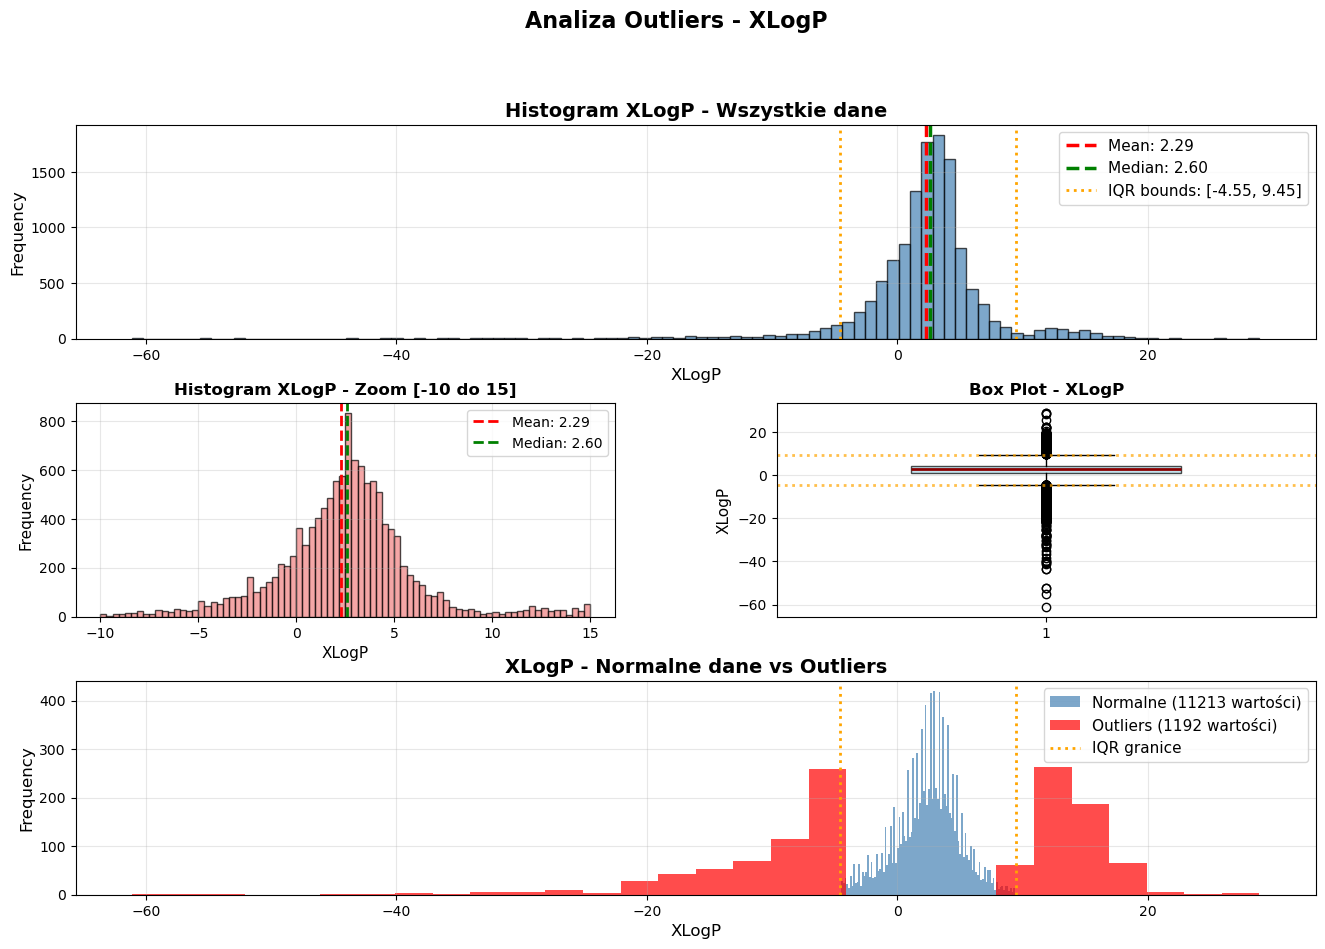


REKOMENDACJE

Na podstawie analizy:

1. Liczba extreme outliers (< -10 lub > 10): 793 (6.39%)

2. Opcje post post powania:

   A) Trzymać WSZYSTKIE dane
      ✅ Bardziej realistyczne
      ⚠️  Model będzie trudniej się uczyć

   B) Usunąć extreme outliers (< -10 lub > 10)
      ✅ Czystsze dane, łatwiejsze trenowanie
      ⚠️  Tracimy 793 próbek

   C) Usunąć outliers IQR
      ✅ Najbardziej czyste dane
      ⚠️  Tracimy 1192 próbek (9.61%)

SUGESTIA: Opcja B - usunąć tylko extreme outliers (< -10 lub > 10)
          To zachowa główną część danych przy zachowaniu jakości trenowania



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===== ANALIZA OUTLIERS =====
print("=" * 80)
print("ANALIZA OUTLIERS - XLogP")
print("=" * 80)

xlogp = df_clean['XLogP']

# Statystyka
Q1 = xlogp.quantile(0.25)
Q3 = xlogp.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nStatystyka IQR:")
print(f"  Q1 (25%): {Q1:.4f}")
print(f"  Q3 (75%): {Q3:.4f}")
print(f"  IQR: {IQR:.4f}")
print(f"  Dolna granica: {lower_bound:.4f}")
print(f"  Górna granica: {upper_bound:.4f}")

# Identyfikacja outliers
outliers_mask = (xlogp < lower_bound) | (xlogp > upper_bound)
n_outliers = outliers_mask.sum()
pct_outliers = (n_outliers / len(xlogp)) * 100

print(f"\nOutliers:")
print(f"  Liczba outliers: {n_outliers}")
print(f"  Procent outliers: {pct_outliers:.2f}%")

# Podział na zakresy
extreme_low = (xlogp < -10).sum()
extreme_high = (xlogp > 10).sum()
moderate_low = (xlogp >= lower_bound) & (xlogp < -10)
moderate_high = (xlogp <= upper_bound) & (xlogp > 10)

print(f"\nRozkład wartości:")
print(f"  Poniżej -10: {extreme_low} wartości")
print(f"  Powyżej 10: {extreme_high} wartości")
print(f"  Pomiędzy -10 a 10: {len(xlogp) - extreme_low - extreme_high} wartości")

# Najekstremalne wartości
print(f"\n10 najniższych wartości XLogP:")
print(xlogp.nsmallest(10).values)
print(f"\n10 najwyższych wartości XLogP:")
print(xlogp.nlargest(10).values)

# ===== WIZUALIZACJA =====
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Histogram - wszystkie dane
ax1 = fig.add_subplot(gs[0, :])
ax1.hist(xlogp, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(xlogp.mean(), color='red', linestyle='--', linewidth=2.5, label=f'Mean: {xlogp.mean():.2f}')
ax1.axvline(xlogp.median(), color='green', linestyle='--', linewidth=2.5, label=f'Median: {xlogp.median():.2f}')
ax1.axvline(lower_bound, color='orange', linestyle=':', linewidth=2, label=f'IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]')
ax1.axvline(upper_bound, color='orange', linestyle=':', linewidth=2)
ax1.set_xlabel('XLogP', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Histogram XLogP - Wszystkie dane', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# 2. Histogram - zoom na główną część (-10 do 15)
ax2 = fig.add_subplot(gs[1, 0])
xlogp_zoom = xlogp[(xlogp >= -10) & (xlogp <= 15)]
ax2.hist(xlogp_zoom, bins=80, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.axvline(xlogp.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {xlogp.mean():.2f}')
ax2.axvline(xlogp.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {xlogp.median():.2f}')
ax2.set_xlabel('XLogP', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Histogram XLogP - Zoom [-10 do 15]', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# 3. Box plot - Vertical
ax3 = fig.add_subplot(gs[1, 1])
bp = ax3.boxplot(xlogp, vert=True, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
bp['medians'][0].set_color('darkred')
bp['medians'][0].set_linewidth(2)
ax3.set_ylabel('XLogP', fontsize=11)
ax3.set_title('Box Plot - XLogP', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3, axis='y')
ax3.axhline(lower_bound, color='orange', linestyle=':', linewidth=2, alpha=0.7)
ax3.axhline(upper_bound, color='orange', linestyle=':', linewidth=2, alpha=0.7)

# 4. Distribution plot z outliers highlighted
ax4 = fig.add_subplot(gs[2, :])
normal_data = xlogp[~outliers_mask]
outlier_data = xlogp[outliers_mask]
ax4.hist(normal_data, bins=100, color='steelblue', alpha=0.7, label=f'Normalne ({len(normal_data)} wartości)')
ax4.hist(outlier_data, bins=30, color='red', alpha=0.7, label=f'Outliers ({len(outlier_data)} wartości)')
ax4.axvline(lower_bound, color='orange', linestyle=':', linewidth=2, label=f'IQR granice')
ax4.axvline(upper_bound, color='orange', linestyle=':', linewidth=2)
ax4.set_xlabel('XLogP', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title('XLogP - Normalne dane vs Outliers', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(alpha=0.3)

plt.suptitle('Analiza Outliers - XLogP', fontsize=16, fontweight='bold', y=0.995)
viz_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\07_pytorch_cl\visualisation\02_xlogp_outliers_analysis.png"
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Wykres zapisany: {viz_path}")
plt.show()

print("\n" + "=" * 80)
print("REKOMENDACJE")
print("=" * 80)
print(f"""
Na podstawie analizy:

1. Liczba extreme outliers (< -10 lub > 10): {extreme_low + extreme_high} ({((extreme_low + extreme_high)/len(xlogp))*100:.2f}%)

2. Opcje post post powania:
   
   A) Trzymać WSZYSTKIE dane
      ✅ Bardziej realistyczne
      ⚠️  Model będzie trudniej się uczyć
   
   B) Usunąć extreme outliers (< -10 lub > 10)
      ✅ Czystsze dane, łatwiejsze trenowanie
      ⚠️  Tracimy {extreme_low + extreme_high} próbek
   
   C) Usunąć outliers IQR
      ✅ Najbardziej czyste dane
      ⚠️  Tracimy {n_outliers} próbek ({pct_outliers:.2f}%)

SUGESTIA: Opcja B - usunąć tylko extreme outliers (< -10 lub > 10)
          To zachowa główną część danych przy zachowaniu jakości trenowania
""")

USUNIĘCIE EXTREME OUTLIERS XLogP (< -10 lub > 10)

Przed usunięciem:
  Liczba wierszy: 12405
  XLogP < -10: 234
  XLogP > 10: 559
  Razem extreme outliers: 793

Po usunięciu:
  Liczba wierszy: 11612
  Usuniętych wierszy: 793
  Procent zachowanych: 93.61%

--------------------------------------------------------------------------------
STATYSTYKA FINALNA - XLogP
--------------------------------------------------------------------------------

count    11612.000000
mean         2.136445
std          2.959870
min        -10.000000
25%          0.700000
50%          2.500000
75%          4.000000
max         10.000000
Name: XLogP, dtype: float64

Min: -10.0000
Max: 10.0000
Mean: 2.1364
Median: 2.5000
Std: 2.9599

--------------------------------------------------------------------------------
SHAPE FINALNE
--------------------------------------------------------------------------------

df_final shape: (11612, 8)
Kolumny: ['Molecular_Weight', 'Polar_Area', 'Complexity', 'XLogP', 'H-Bond_Do

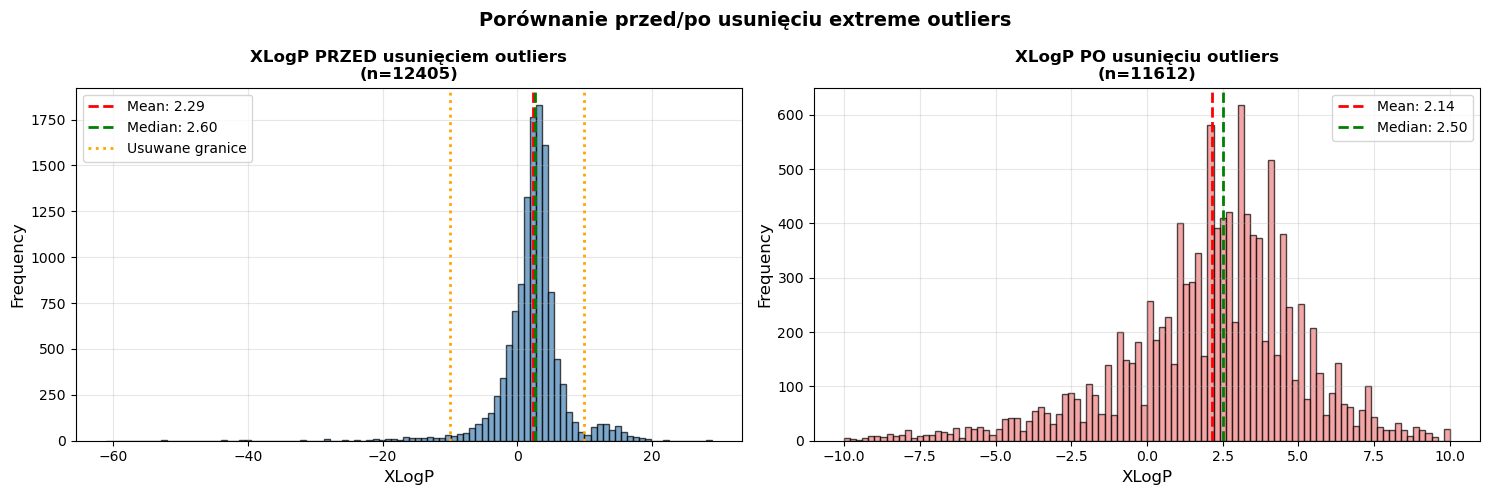


✅ DANE GOTOWE DO PREPROCESSINGU!

df_final: 11612 wierszy × 8 kolumn


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== KROK 1: PRZED USUNIĘCIEM =====
print("=" * 80)
print("USUNIĘCIE EXTREME OUTLIERS XLogP (< -10 lub > 10)")
print("=" * 80)

n_before = len(df_clean)
xlogp_before = df_clean['XLogP']

extreme_low = (df_clean['XLogP'] < -10).sum()
extreme_high = (df_clean['XLogP'] > 10).sum()
n_extreme = extreme_low + extreme_high

print(f"\nPrzed usunięciem:")
print(f"  Liczba wierszy: {n_before}")
print(f"  XLogP < -10: {extreme_low}")
print(f"  XLogP > 10: {extreme_high}")
print(f"  Razem extreme outliers: {n_extreme}")

# ===== KROK 2: USUŃ EXTREME OUTLIERS =====
df_final = df_clean[(df_clean['XLogP'] >= -10) & (df_clean['XLogP'] <= 10)].reset_index(drop=True)

n_after = len(df_final)
n_removed = n_before - n_after

print(f"\nPo usunięciu:")
print(f"  Liczba wierszy: {n_after}")
print(f"  Usuniętych wierszy: {n_removed}")
print(f"  Procent zachowanych: {(n_after/n_before)*100:.2f}%")

# ===== KROK 3: STATYSTYKA =====
print(f"\n{'-' * 80}")
print(f"STATYSTYKA FINALNA - XLogP")
print(f"{'-' * 80}")

xlogp_final = df_final['XLogP']
print(f"\n{xlogp_final.describe()}")

print(f"\nMin: {xlogp_final.min():.4f}")
print(f"Max: {xlogp_final.max():.4f}")
print(f"Mean: {xlogp_final.mean():.4f}")
print(f"Median: {xlogp_final.median():.4f}")
print(f"Std: {xlogp_final.std():.4f}")

# ===== KROK 4: WERYFIKACJA =====
print(f"\n{'-' * 80}")
print(f"SHAPE FINALNE")
print(f"{'-' * 80}")
print(f"\ndf_final shape: {df_final.shape}")
print(f"Kolumny: {df_final.columns.tolist()}")

print(f"\nBrakujące wartości w df_final:")
print(df_final.isnull().sum())

print(f"\nPierwsze 5 wierszy df_final:")
print(df_final.head())

# ===== KROK 5: WIZUALIZACJA PRZED/PO =====
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Przed
axes[0].hist(xlogp_before, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(xlogp_before.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {xlogp_before.mean():.2f}')
axes[0].axvline(xlogp_before.median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {xlogp_before.median():.2f}')
axes[0].axvline(-10, color='orange', linestyle=':', linewidth=2, label='Usuwane granice')
axes[0].axvline(10, color='orange', linestyle=':', linewidth=2)
axes[0].set_xlabel('XLogP', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'XLogP PRZED usunięciem outliers\n(n={len(xlogp_before)})', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Po
axes[1].hist(xlogp_final, bins=100, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(xlogp_final.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {xlogp_final.mean():.2f}')
axes[1].axvline(xlogp_final.median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {xlogp_final.median():.2f}')
axes[1].set_xlabel('XLogP', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'XLogP PO usunięciu outliers\n(n={len(xlogp_final)})', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('Porównanie przed/po usunięciu extreme outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
viz_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\07_pytorch_cl\visualisation\03_xlogp_before_after_outliers.png"
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Wykres zapisany: {viz_path}")
plt.show()

print("\n" + "=" * 80)
print("✅ DANE GOTOWE DO PREPROCESSINGU!")
print("=" * 80)
print(f"\ndf_final: {df_final.shape[0]} wierszy × {df_final.shape[1]} kolumn")

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle

# ===== KROK 1: PRZYGOTOWANIE =====
print("=" * 80)
print("SKALOWANIE FEATURES I ZAPIS DO CSV")
print("=" * 80)

# Kolumny do skalowania (features)
feature_cols = ['Molecular_Weight', 'Polar_Area', 'Complexity', 
                'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count']

target_col = 'XLogP'
smiles_col = 'SMILES'

print(f"\nKolumny do skalowania (features): {feature_cols}")
print(f"Target (bez skalowania): {target_col}")
print(f"SMILES: {smiles_col}")

# ===== KROK 2: SKALOWANIE =====
print(f"\n{'-' * 80}")
print(f"SKALOWANIE FEATURES")
print(f"{'-' * 80}")

scaler = StandardScaler()
df_final[feature_cols] = scaler.fit_transform(df_final[feature_cols])

print(f"\nParametry skalowania:")
print(f"\nMean (przed skalowaniem):")
for col, mean_val in zip(feature_cols, scaler.mean_):
    print(f"  {col}: {mean_val:.4f}")

print(f"\nStd (przed skalowaniem):")
for col, std_val in zip(feature_cols, scaler.scale_):
    print(f"  {col}: {std_val:.4f}")

# ===== KROK 3: WERYFIKACJA SKALOWANIA =====
print(f"\n{'-' * 80}")
print(f"WERYFIKACJA - STATYSTYKA PO SKALOWANIU")
print(f"{'-' * 80}")

print(f"\nSkalowane features (mean ≈ 0, std ≈ 1):")
print(df_final[feature_cols].describe())

print(f"\nXLogP (bez zmian):")
print(df_final[target_col].describe())

# ===== KROK 4: SPRAWDZENIE DANYCH =====
print(f"\n{'-' * 80}")
print(f"FINALNY DF")
print(f"{'-' * 80}")

print(f"\nShape: {df_final.shape}")
print(f"Kolumny: {df_final.columns.tolist()}")
print(f"\nPierwsze 5 wierszy:")
print(df_final.head())

print(f"\nBrakujące wartości:")
print(df_final.isnull().sum())

# ===== KROK 5: ZAPIS PREPROCESSOWANEGO CSV =====
print(f"\n{'-' * 80}")
print(f"ZAPIS PLIKÓW")
print(f"{'-' * 80}")

csv_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\07_pytorch_cl\data\procced\data_preprocessed.csv"
df_final.to_csv(csv_path, index=False)
print(f"\n✅ CSV zapisany: {csv_path}")

# ===== KROK 6: ZAPIS PARAMETRÓW SKALOWANIA =====
scaler_params = {
    'feature_cols': feature_cols,
    'mean': dict(zip(feature_cols, scaler.mean_)),
    'scale': dict(zip(feature_cols, scaler.scale_)),  # to jest std
}

scaler_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\07_pytorch_cl\data\procced\scaler_params.pkl"
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler_params, f)
print(f"✅ Parametry skalowania zapisane: {scaler_path}")

# ===== KROK 7: PODSUMOWANIE =====
print(f"\n{'-' * 80}")
print(f"PODSUMOWANIE")
print(f"{'-' * 80}")

print(f"""
📊 Dane preprocessowane:
  - Liczba wierszy: {df_final.shape[0]}
  - Liczba kolumn: {df_final.shape[1]}
  
📁 Pliki zapisane:
  1. CSV: {csv_path}
  2. Parametry skalowania: {scaler_path}

✅ Dane gotowe do trenowania modelu PyTorch!

Następne kroki:
  1. Załaduj: data_preprocessed.csv
  2. Przygotuj SMILES (embedding/fingerprints)
  3. Utwórz DataLoader
  4. Zbuduj model PyTorch
  5. Trenuj model
""")

print("\n✅ KONIEC PREPROCESSINGU - ZARAZ BĘDZIESZ PRACOWAĆ NA NOWYM PLIKU!")

SKALOWANIE FEATURES I ZAPIS DO CSV

Kolumny do skalowania (features): ['Molecular_Weight', 'Polar_Area', 'Complexity', 'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count']
Target (bez skalowania): XLogP
SMILES: SMILES

--------------------------------------------------------------------------------
SKALOWANIE FEATURES
--------------------------------------------------------------------------------

Parametry skalowania:

Mean (przed skalowaniem):
  Molecular_Weight: 436.8103
  Polar_Area: 118.0237
  Complexity: 700.3964
  H-Bond_Donor_Count: 2.8029
  H-Bond_Acceptor_Count: 6.8396
  Rotatable_Bond_Count: 7.2408

Std (przed skalowaniem):
  Molecular_Weight: 414.0727
  Polar_Area: 172.7111
  Complexity: 1051.7273
  H-Bond_Donor_Count: 4.8879
  H-Bond_Acceptor_Count: 8.0405
  Rotatable_Bond_Count: 11.1199

--------------------------------------------------------------------------------
WERYFIKACJA - STATYSTYKA PO SKALOWANIU
------------------------------------------------

WIZUALIZACJA ROZKŁADÓW - PRZED I PO SKALOWANIU

✅ Wykres zapisany: C:\Users\slast\PYTHON\0_projekty do portfolio\07_pytorch_cl\visualisation\04_features_scaling_comparison.png


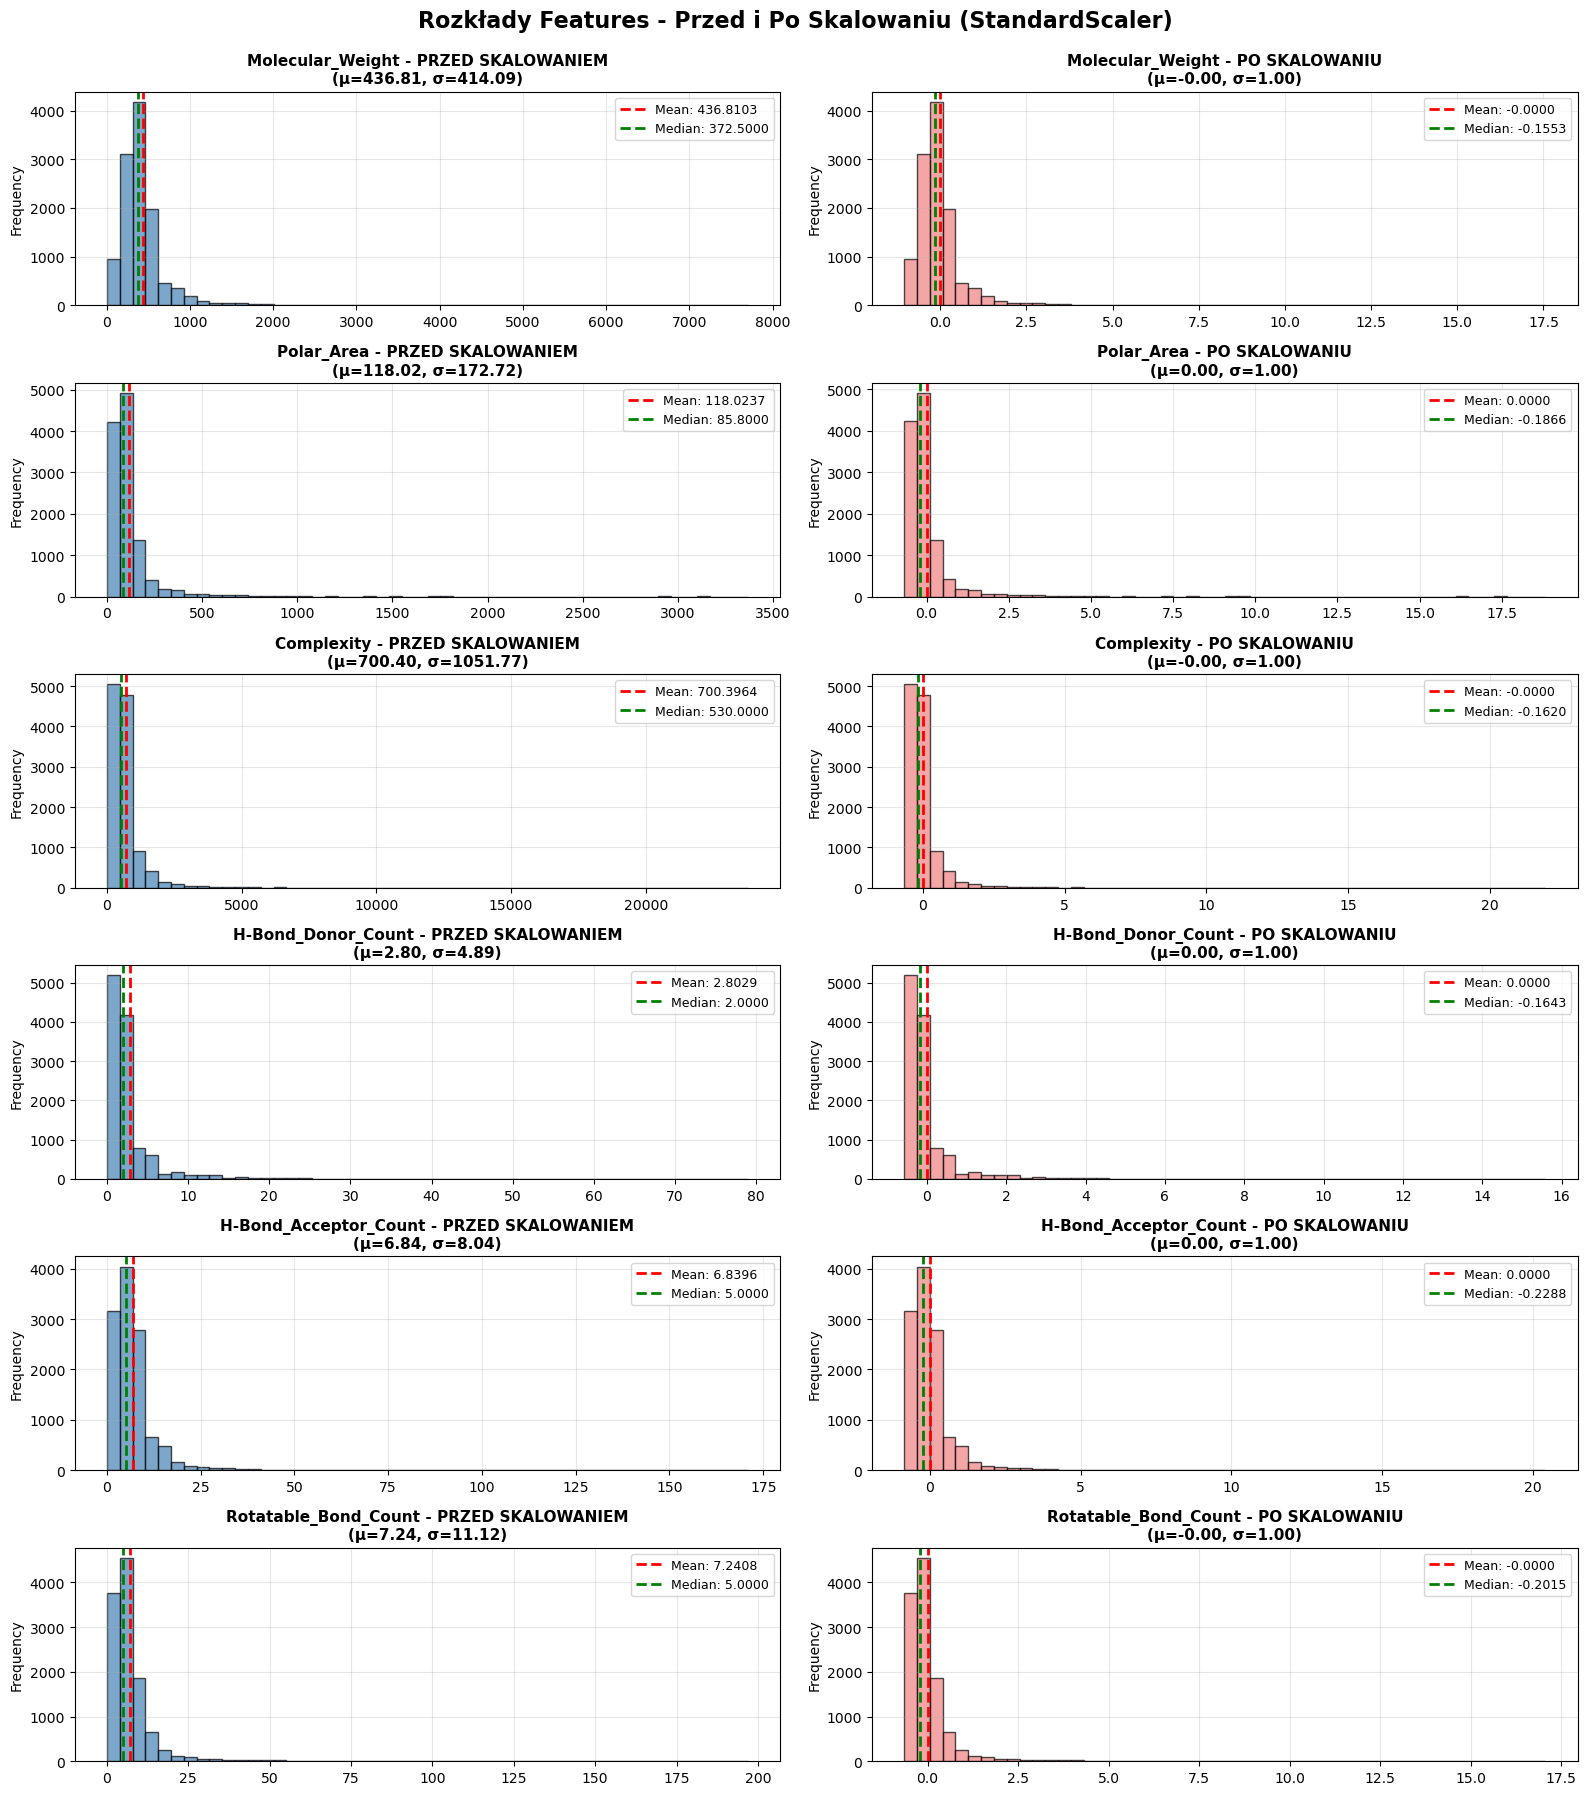


--------------------------------------------------------------------------------
PODSUMOWANIE STATYSTYK
--------------------------------------------------------------------------------

              Kolumna PRZED - Mean PRZED - Std PRZED - Min PRZED - Max PO - Mean PO - Std PO - Min PO - Max
     Molecular_Weight     436.8103    414.0905      1.0080   7707.0000   -0.0000   1.0000  -1.0525  17.5578
           Polar_Area     118.0237    172.7185      0.0000   3370.0000    0.0000   1.0000  -0.6834  18.8290
           Complexity     700.3964   1051.7726      0.0000  23800.0000   -0.0000   1.0000  -0.6659  21.9635
   H-Bond_Donor_Count       2.8029      4.8881      0.0000     79.0000    0.0000   1.0000  -0.5734  15.5890
H-Bond_Acceptor_Count       6.8396      8.0408      0.0000    171.0000    0.0000   1.0000  -0.8507  20.4167
 Rotatable_Bond_Count       7.2408     11.1204      0.0000    197.0000   -0.0000   1.0000  -0.6512  17.0648

--------------------------------------------------------

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Załaduj raw data do porównania
raw_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\07_pytorch_cl\data\raw\RAW.csv"
df_raw = pd.read_csv(raw_path)

# Filtry - takie same jak stosowaliśmy
feature_cols = ['Molecular_Weight', 'Polar_Area', 'Complexity', 
                'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count']

# Przygotuj dane raw (przed skalowaniem)
df_raw_clean = df_raw.dropna(subset=['XLogP'])
df_raw_clean = df_raw_clean[(df_raw_clean['XLogP'] >= -10) & (df_raw_clean['XLogP'] <= 10)].reset_index(drop=True)
df_raw_before = df_raw_clean[feature_cols].copy()

# Skalowanie
scaler = StandardScaler()
df_after = pd.DataFrame(
    scaler.fit_transform(df_raw_before),
    columns=feature_cols
)

# ===== WIZUALIZACJA =====
print("=" * 80)
print("WIZUALIZACJA ROZKŁADÓW - PRZED I PO SKALOWANIU")
print("=" * 80)

fig, axes = plt.subplots(6, 2, figsize=(16, 18))
fig.suptitle('Rozkłady Features - Przed i Po Skalowaniu (StandardScaler)', 
             fontsize=16, fontweight='bold', y=0.995)

for idx, col in enumerate(feature_cols):
    # PRZED skalowaniem
    axes[idx, 0].hist(df_raw_before[col], bins=50, color='steelblue', 
                      edgecolor='black', alpha=0.7)
    axes[idx, 0].axvline(df_raw_before[col].mean(), color='red', linestyle='--', 
                         linewidth=2, label=f'Mean: {df_raw_before[col].mean():.4f}')
    axes[idx, 0].axvline(df_raw_before[col].median(), color='green', linestyle='--', 
                         linewidth=2, label=f'Median: {df_raw_before[col].median():.4f}')
    axes[idx, 0].set_ylabel('Frequency', fontsize=10)
    axes[idx, 0].set_title(f'{col} - PRZED SKALOWANIEM\n(μ={df_raw_before[col].mean():.2f}, σ={df_raw_before[col].std():.2f})', 
                          fontsize=11, fontweight='bold')
    axes[idx, 0].legend(fontsize=9)
    axes[idx, 0].grid(alpha=0.3)
    
    # PO skalowaniu
    axes[idx, 1].hist(df_after[col], bins=50, color='lightcoral', 
                      edgecolor='black', alpha=0.7)
    axes[idx, 1].axvline(df_after[col].mean(), color='red', linestyle='--', 
                         linewidth=2, label=f'Mean: {df_after[col].mean():.4f}')
    axes[idx, 1].axvline(df_after[col].median(), color='green', linestyle='--', 
                         linewidth=2, label=f'Median: {df_after[col].median():.4f}')
    axes[idx, 1].set_ylabel('Frequency', fontsize=10)
    axes[idx, 1].set_title(f'{col} - PO SKALOWANIU\n(μ={df_after[col].mean():.2f}, σ={df_after[col].std():.2f})', 
                          fontsize=11, fontweight='bold')
    axes[idx, 1].legend(fontsize=9)
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
viz_path = r"C:\Users\slast\PYTHON\0_projekty do portfolio\07_pytorch_cl\visualisation\04_features_scaling_comparison.png"
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Wykres zapisany: {viz_path}")
plt.show()

# ===== TABELA PORÓWNAWCZA =====
print(f"\n{'-' * 80}")
print(f"PODSUMOWANIE STATYSTYK")
print(f"{'-' * 80}")

summary_data = []
for col in feature_cols:
    summary_data.append({
        'Kolumna': col,
        'PRZED - Mean': f"{df_raw_before[col].mean():.4f}",
        'PRZED - Std': f"{df_raw_before[col].std():.4f}",
        'PRZED - Min': f"{df_raw_before[col].min():.4f}",
        'PRZED - Max': f"{df_raw_before[col].max():.4f}",
        'PO - Mean': f"{df_after[col].mean():.4f}",
        'PO - Std': f"{df_after[col].std():.4f}",
        'PO - Min': f"{df_after[col].min():.4f}",
        'PO - Max': f"{df_after[col].max():.4f}",
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print(f"\n{'-' * 80}")
print(f"OBSERWACJE")
print(f"{'-' * 80}")
print("""
✅ StandardScaler:
   - Zmienia Mean na ≈ 0
   - Zmienia Std na ≈ 1
   - Zachowuje kształt rozkładu
   - Wszystkie features na tej samej skali
   
💡 To pozwala sieci neuronowej:
   - Lepiej się uczyć (gradient descent bardziej stabilny)
   - Szybciej się zbiegać
   - Unikać problemów z dużymi liczbami
""")

print("\n✅ ROZKŁADY PORÓWNANE!")